In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('rides_Clean_data.csv')

In [3]:
df.head()

,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,total_fare,payment_method,Hour,day_name,month,month_number,day_type,Route,Distance_Category
0,cab economy,7/15/2024,8:30:41 AM,completed,Balagere Harbor,Harohalli Nagar,39,RD3161218751875354,27.21,764.83,31.51,796.34,Amazon Pay,8,Monday,July,7,Weekday,Balagere Harbor > Harohalli Nagar,Very Long
1,auto,7/5/2024,11:36:52 PM,completed,Basavanagudi 3rd Block,Bikasipura 1st Stage,89,RD8171514284594096,34.03,314.83,49.52,364.35,Paytm,23,Friday,July,7,Weekday,Basavanagudi 3rd Block > Bikasipura 1st Stage,Very Long
2,auto,7/23/2024,11:05:38 AM,cancelled,Babusapalya Cove,Kothaguda Terrace,25,RD9376481122237926,20.24,0.00,0.00,0.00,NaN,11,Tuesday,July,7,Weekday,Babusapalya Cove > Kothaguda Terrace,Very Long
3,cab economy,6/24/2024,8:45:11 AM,completed,Mahadevapura Mews,Kanakapura Arc,89,RD3676889143182765,31.17,484.73,15.84,500.57,QR scan,8,Monday,June,6,Weekday,Mahadevapura Mews > Kanakapura Arc,Very Long
4,cab economy,7/15/2024,12:26:45 AM,completed,Ganganagar Cove,Basaveshwaranagar Colony,95,RD6639410275948084,27.21,663.50,14.13,677.63,Amazon Pay,0,Monday,July,7,Weekday,Ganganagar Cove > Basaveshwaranagar Colony,Very Long


In [4]:
df.columns

Index(['services', 'date', 'time', 'ride_status', 'source', 'destination',
       'duration', 'ride_id', 'distance', 'ride_charge', 'misc_charge',
       'total_fare', 'payment_method', 'Hour', 'day_name', 'month',
       'month_number', 'day_type', 'Route', 'Distance_Category'],
      dtype='str')

In [5]:
df.shape

(50000, 20)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   services           50000 non-null  str    
 1   date               50000 non-null  str    
 2   time               50000 non-null  str    
 3   ride_status        50000 non-null  str    
 4   source             50000 non-null  str    
 5   destination        50000 non-null  str    
 6   duration           50000 non-null  int64  
 7   ride_id            50000 non-null  str    
 8   distance           50000 non-null  float64
 9   ride_charge        50000 non-null  float64
 10  misc_charge        50000 non-null  float64
 11  total_fare         50000 non-null  float64
 12  payment_method     44964 non-null  str    
 13  Hour               50000 non-null  int64  
 14  day_name           50000 non-null  str    
 15  month              50000 non-null  str    
 16  month_number       50000 non-null

In [7]:
df.isnull().sum()

services                0
date                    0
time                    0
ride_status             0
source                  0
destination             0
duration                0
ride_id                 0
distance                0
ride_charge             0
misc_charge             0
total_fare              0
payment_method       5036
Hour                    0
day_name                0
month                   0
month_number            0
day_type                0
Route                   0
Distance_Category       0
dtype: int64

In [8]:
df[df.isnull().any(axis=1)].head()

,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,total_fare,payment_method,Hour,day_name,month,month_number,day_type,Route,Distance_Category
2,auto,7/23/2024,11:05:38 AM,cancelled,Babusapalya Cove,Kothaguda Terrace,25,RD9376481122237926,20.24,0.0,0.0,0.0,NaN,11,Tuesday,July,7,Weekday,Babusapalya Cove > Kothaguda Terrace,Very Long
13,parcel,8/15/2024,10:59:05 PM,cancelled,Bhadrappa Layout Vista,Subramanyapura Road,82,RD0256680118366791,29.83,0.0,0.0,0.0,NaN,22,Thursday,August,8,Weekday,Bhadrappa Layout Vista > Subramanyapura Road,Very Long
14,bike,7/22/2024,1:07:17 PM,cancelled,Frazer Town Works,Hebbal Kempapura Viewpoint,44,RD7115059402806582,49.92,0.0,0.0,0.0,NaN,13,Monday,July,7,Weekday,Frazer Town Works > Hebbal Kempapura Viewpoint,Very Long
29,cab economy,7/20/2024,12:24:51 PM,cancelled,Vidyaranyapura Summit,Agara Mews,48,RD8925634951822521,7.05,0.0,0.0,0.0,NaN,12,Saturday,July,7,Weekend,Vidyaranyapura Summit > Agara Mews,Long
31,auto,7/6/2024,11:05:32 AM,cancelled,Chikkagubbi Village,Horamavu Banaswadi Alcove,118,RD7321545592072979,9.25,0.0,0.0,0.0,NaN,11,Saturday,July,7,Weekend,Chikkagubbi Village > Horamavu Banaswadi Alcove,Long


In [9]:
df['payment_method'] = df['payment_method'].fillna('Not Applicable')

In [10]:
df.isnull().sum()

services             0
date                 0
time                 0
ride_status          0
source               0
destination          0
duration             0
ride_id              0
distance             0
ride_charge          0
misc_charge          0
total_fare           0
payment_method       0
Hour                 0
day_name             0
month                0
month_number         0
day_type             0
Route                0
Distance_Category    0
dtype: int64

In [11]:
df['payment_method'].value_counts()

payment_method
Paytm             11315
GPay              11268
Amazon Pay        11225
QR scan           11156
Not Applicable     5036
Name: count, dtype: int64

In [12]:
df['payment_method'].value_counts()

payment_method
Paytm             11315
GPay              11268
Amazon Pay        11225
QR scan           11156
Not Applicable     5036
Name: count, dtype: int64

In [13]:
df['date'] = pd.to_datetime(df['date'])

In [14]:
df['time'] = pd.to_datetime(df['time'], format='%I:%M:%S %p').dt.time

In [15]:
df[['date', 'time']].head()

,date,time
0,2024-07-15,08:30:41
1,2024-07-05,23:36:52
2,2024-07-23,11:05:38
3,2024-06-24,08:45:11
4,2024-07-15,00:26:45


In [16]:
df[['date', 'time']].dtypes

date    datetime64[us]
time            object
dtype: object

In [17]:
df.isnull().sum()

services             0
date                 0
time                 0
ride_status          0
source               0
destination          0
duration             0
ride_id              0
distance             0
ride_charge          0
misc_charge          0
total_fare           0
payment_method       0
Hour                 0
day_name             0
month                0
month_number         0
day_type             0
Route                0
Distance_Category    0
dtype: int64

In [18]:
df['ride_id'].duplicated().sum()

np.int64(0)

In [19]:
print("Negative distance:", (df['distance'] < 0).sum())
print("Negative ride charge:", (df['ride_charge'] < 0).sum())
print("Negative misc charge:", (df['misc_charge'] < 0).sum())
print("Negative total fare:", (df['total_fare'] < 0).sum())

Negative distance: 0
Negative ride charge: 0
Negative misc charge: 0
Negative total fare: 0


In [20]:
fare_mismatch = (
    df['total_fare'].round(2) !=
    (df['ride_charge'] + df['misc_charge']).round(2)
)

fare_mismatch.sum()

np.int64(0)

In [21]:
df.describe()

,date,duration,distance,ride_charge,misc_charge,total_fare,Hour,month_number
count,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2024-07-17 03:21:27.359999,64.320100,25.528243,469.809776,22.449885,492.259661,11.490020,7.037880
min,2024-06-17 00:00:00,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,6.000000
25%,2024-07-02 00:00:00,37.000000,13.260000,205.207500,8.190000,229.360000,6.000000,7.000000
50%,2024-07-17 00:00:00,64.000000,25.460000,466.770000,22.210000,491.350000,11.000000,7.000000
75%,2024-08-01 00:00:00,92.000000,37.860000,733.267500,36.060000,758.415000,17.000000,8.000000
max,2024-08-16 00:00:00,119.000000,50.000000,999.960000,50.000000,1048.800000,23.000000,8.000000
std,NaN,31.852336,14.177136,304.292438,15.635392,308.537369,6.891697,0.698237


In [22]:
df.describe(include='object')

C:\Users\Dhaval Darji\AppData\Local\Temp\ipykernel_13136\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,services,time,ride_status,source,destination,ride_id,payment_method,day_name,month,day_type,Route,Distance_Category
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,5,38006,2,12982,12977,50000,5,7,3,2,49993,4
top,bike,09:10:02,completed,Kothanur Landing,Gottigere Landing,RD3161218751875354,Paytm,Monday,July,Weekday,Jayanagar Cut > Yelahanka Landing,Very Long
freq,15128,6,44964,23,23,1,11315,7432,25552,36876,2,35747


In [23]:
df['services'].value_counts()

services
bike           15128
auto           12327
cab economy    10202
parcel          7459
bike lite       4884
Name: count, dtype: int64

In [24]:
df['ride_status'].value_counts()

ride_status
completed    44964
cancelled     5036
Name: count, dtype: int64

In [25]:
print("Total Revenue:", df['total_fare'].sum())
print("Average Fare:", df['total_fare'].mean())
print("Average Distance:", df['distance'].mean())
print("Average Duration:", df['duration'].mean())

Total Revenue: 24612983.05
Average Fare: 492.259661
Average Distance: 25.5282432
Average Duration: 64.3201


In [26]:
service_analysis = df.groupby('services').agg(
    Total_Rides=('ride_id', 'count'),
    Completed_Rides=('ride_status', lambda x: (x == 'completed').sum()),
    Cancelled_Rides=('ride_status', lambda x: (x == 'cancelled').sum()),
    Total_Revenue=('total_fare', 'sum'),
    Average_Fare=('total_fare', 'mean'),
    Average_Distance=('distance', 'mean'),
    Average_Duration=('duration', 'mean')
).reset_index()

service_analysis

,services,Total_Rides,Completed_Rides,Cancelled_Rides,Total_Revenue,Average_Fare,Average_Distance,Average_Duration
0,auto,12327,11114,1213,6099731.32,494.826910,25.595676,64.916849
1,bike,15128,13567,1561,7432783.95,491.326279,25.385639,63.925172
2,bike lite,4884,4388,496,2387720.59,488.886280,25.700749,64.117936
3,cab economy,10202,9148,1054,5006233.04,490.710943,25.497436,64.247893
4,parcel,7459,6747,712,3686514.15,494.237049,25.635208,64.366001


In [27]:
service_analysis['Cancellation_Rate'] = (
    service_analysis['Cancelled_Rides'] /
    service_analysis['Total_Rides'] * 100
).round(2)

In [28]:
service_analysis

,services,Total_Rides,Completed_Rides,Cancelled_Rides,Total_Revenue,Average_Fare,Average_Distance,Average_Duration,Cancellation_Rate
0,auto,12327,11114,1213,6099731.32,494.826910,25.595676,64.916849,9.84
1,bike,15128,13567,1561,7432783.95,491.326279,25.385639,63.925172,10.32
2,bike lite,4884,4388,496,2387720.59,488.886280,25.700749,64.117936,10.16
3,cab economy,10202,9148,1054,5006233.04,490.710943,25.497436,64.247893,10.33
4,parcel,7459,6747,712,3686514.15,494.237049,25.635208,64.366001,9.55


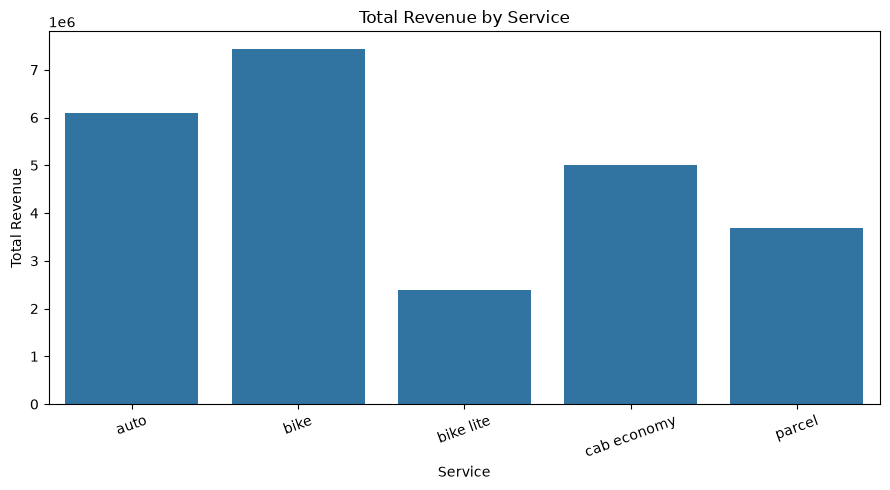

In [29]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=service_analysis,
    x='services',
    y='Total_Revenue'
)

plt.title('Total Revenue by Service')
plt.xlabel('Service')
plt.ylabel('Total Revenue')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

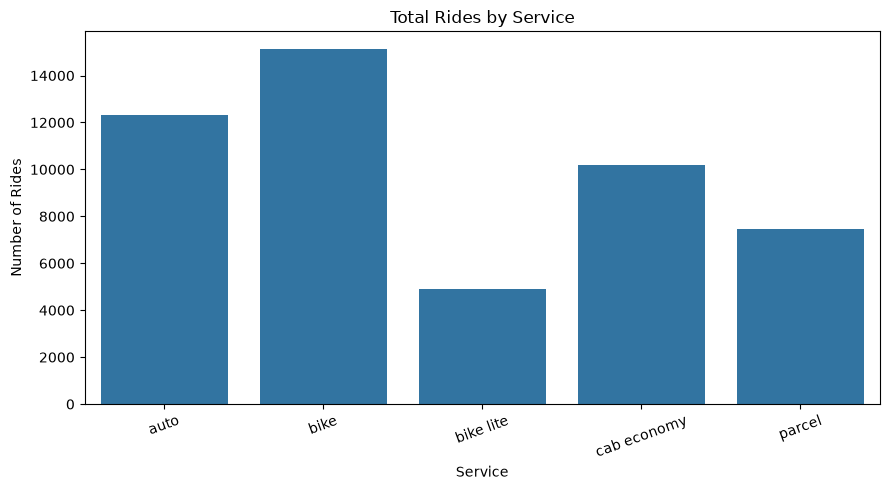

In [30]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=service_analysis,
    x='services',
    y='Total_Rides'
)

plt.title('Total Rides by Service')
plt.xlabel('Service')
plt.ylabel('Number of Rides')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [31]:
# Convert time column to datetime
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')

# Extract hour
df['Hour'] = df['time'].dt.hour

# Check result
df[['time', 'Hour']].head()

,time,Hour
0,1900-01-01 08:30:41,8
1,1900-01-01 23:36:52,23
2,1900-01-01 11:05:38,11
3,1900-01-01 08:45:11,8
4,1900-01-01 00:26:45,0


In [32]:
hourly_rides = (
    df.groupby('Hour')
      .size()
      .reset_index(name='Total_Rides')
)

hourly_rides

,Hour,Total_Rides
0,0,2036
1,1,2106
2,2,2001
3,3,2066
4,4,2081
5,5,2102
6,6,2075
7,7,2111
8,8,2104
9,9,2187


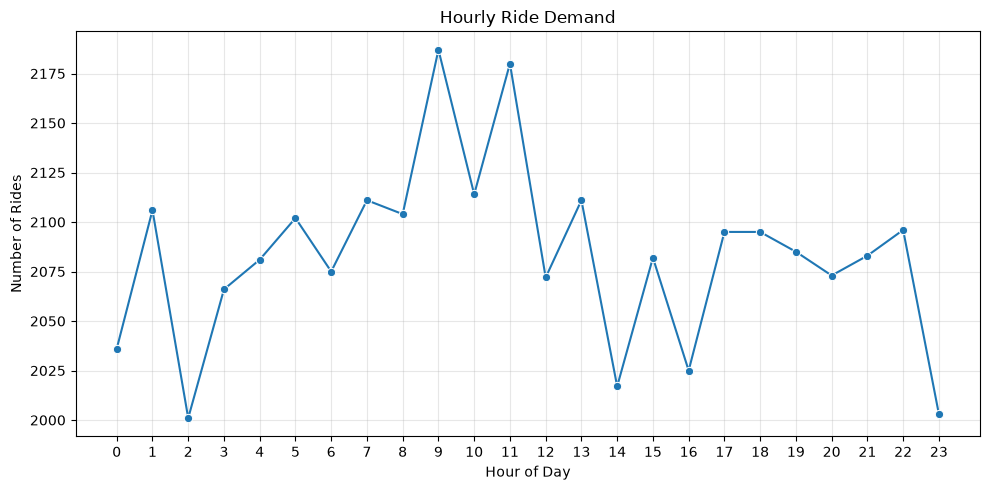

In [33]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hourly_rides,
    x='Hour',
    y='Total_Rides',
    marker='o'
)

plt.title('Hourly Ride Demand')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [34]:
day_analysis = (
    df.groupby('day_name')
      .size()
      .reset_index(name='Total_Rides')
)

day_analysis

,day_name,Total_Rides
0,Friday,7329
1,Monday,7432
2,Saturday,6584
3,Sunday,6540
4,Thursday,7404
5,Tuesday,7384
6,Wednesday,7327


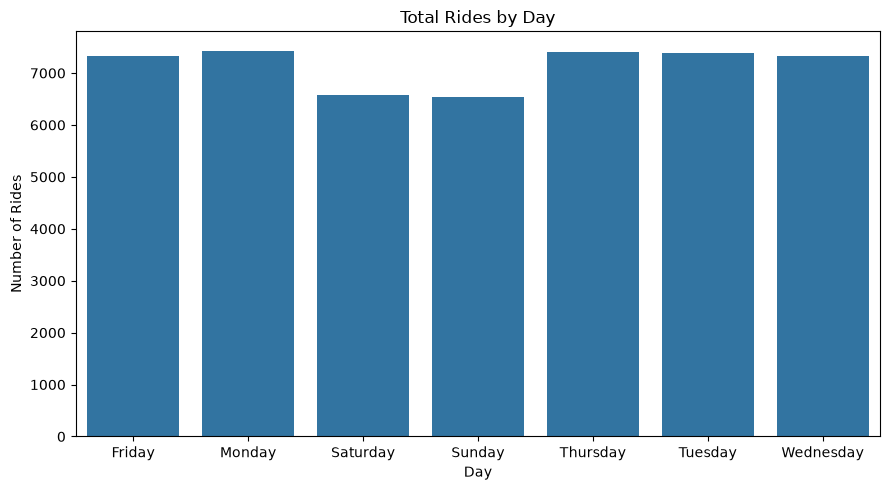

In [35]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=day_analysis,
    x='day_name',
    y='Total_Rides'
)

plt.title('Total Rides by Day')
plt.xlabel('Day')
plt.ylabel('Number of Rides')
plt.tight_layout()

plt.show()

In [36]:
day_type_analysis = (
    df.groupby('day_type')
      .size()
      .reset_index(name='Total_Rides')
)

day_type_analysis

,day_type,Total_Rides
0,Weekday,36876
1,Weekend,13124


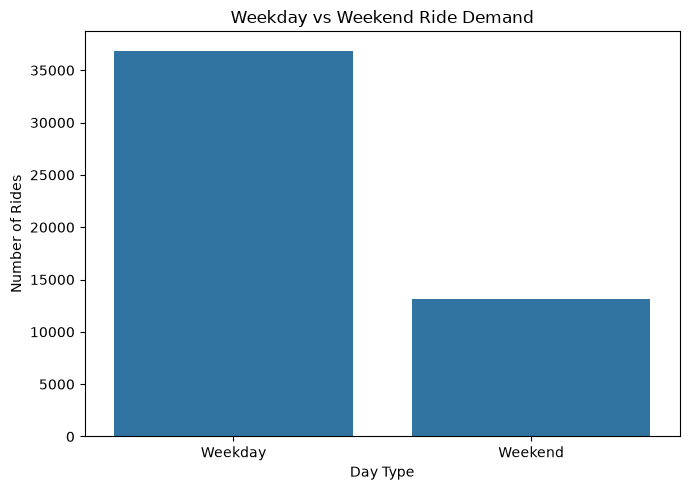

In [37]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=day_type_analysis,
    x='day_type',
    y='Total_Rides'
)

plt.title('Weekday vs Weekend Ride Demand')
plt.xlabel('Day Type')
plt.ylabel('Number of Rides')
plt.tight_layout()

plt.show()

In [38]:
monthly_analysis = (
    df.groupby(['month_number', 'month'])
      .agg(
          Total_Rides=('ride_id', 'count'),
          Total_Revenue=('total_fare', 'sum')
      )
      .reset_index()
      .sort_values('month_number')
)

monthly_analysis

,month_number,month,Total_Rides,Total_Revenue
0,6,June,11277,5548695.60
1,7,July,25552,12516755.80
2,8,August,13171,6547531.65


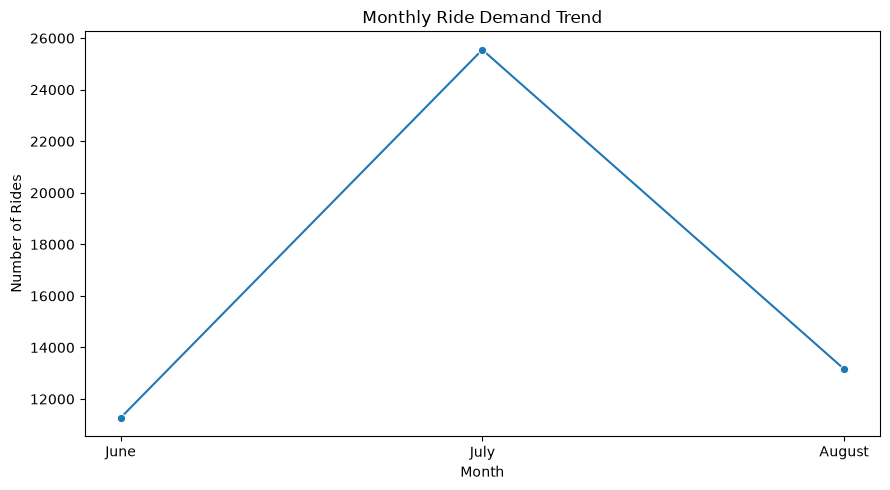

In [39]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=monthly_analysis,
    x='month',
    y='Total_Rides',
    marker='o'
)

plt.title('Monthly Ride Demand Trend')
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.tight_layout()

plt.show()

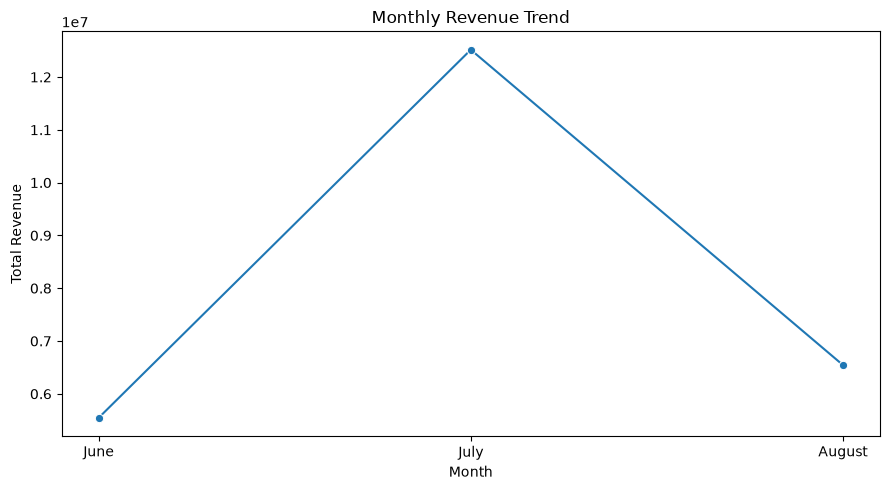

In [40]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=monthly_analysis,
    x='month',
    y='Total_Revenue',
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.tight_layout()

plt.show()

In [41]:
route_analysis = (
    df.groupby('Route')
      .agg(
          Total_Rides=('ride_id', 'count'),
          Total_Revenue=('total_fare', 'sum'),
          Average_Fare=('total_fare', 'mean')
      )
      .reset_index()
      .sort_values('Total_Rides', ascending=False)
)

route_analysis.head(10)

,Route,Total_Rides,Total_Revenue,Average_Fare
24976,Jayanagar Cut > Yelahanka Landing,2,822.62,411.310
1529,Anekal Woods > Yelahanka Complex,2,657.56,328.780
6462,Basaveshwaranagar Place > Kalena Agrahara Fork,2,1008.06,504.030
18379,HSR Layout Crescent > Tavarekere View,2,704.24,352.120
33248,Kundalahalli 6th Stage > Gottigere 5th Stage,2,1616.41,808.205
34776,Magadi Road 5th Stage > Rachenahalli Landing,2,574.35,287.175
37019,Naganathapura Close > Koramangala 7th Block Vista,2,1384.42,692.210
3,Adugodi 1st Stage > Kanakapura Esplanade,1,0.00,0.000
4,Adugodi 1st Stage > Ulsoor Complex,1,647.59,647.590
5,Adugodi 2nd Block > Attibele Valley,1,331.10,331.100


In [42]:
route_analysis = (
    df.groupby('Route')
      .agg(
          Total_Rides=('ride_id', 'count'),
          Total_Revenue=('total_fare', 'sum'),
          Average_Fare=('total_fare', 'mean')
      )
      .reset_index()
)

route_analysis = (
    route_analysis[route_analysis['Total_Rides'] >= 2]
    .sort_values('Total_Rides', ascending=False)
)

route_analysis.head(10)

,Route,Total_Rides,Total_Revenue,Average_Fare
1529,Anekal Woods > Yelahanka Complex,2,657.56,328.780
6462,Basaveshwaranagar Place > Kalena Agrahara Fork,2,1008.06,504.030
18379,HSR Layout Crescent > Tavarekere View,2,704.24,352.120
24976,Jayanagar Cut > Yelahanka Landing,2,822.62,411.310
33248,Kundalahalli 6th Stage > Gottigere 5th Stage,2,1616.41,808.205
34776,Magadi Road 5th Stage > Rachenahalli Landing,2,574.35,287.175
37019,Naganathapura Close > Koramangala 7th Block Vista,2,1384.42,692.210


In [43]:
source_analysis = (
    df.groupby('source')
      .agg(
          Total_Rides=('ride_id', 'count'),
          Total_Revenue=('total_fare', 'sum'),
          Average_Fare=('total_fare', 'mean')
      )
      .reset_index()
      .sort_values('Total_Rides', ascending=False)
)

source_analysis.head(10)

,source,Total_Rides,Total_Revenue,Average_Fare
8162,Kothanur Landing,23,10956.33,476.362174
1407,Banaswadi Landing,20,8924.59,446.229500
12539,Vijayanagar Square,20,9569.66,478.483000
4650,HRBR Layout Landing,19,8862.17,466.430000
10804,Ramamurthy Nagar Landing,18,9624.97,534.720556
1431,Banaswadi Square,17,9323.49,548.440588
4674,HRBR Layout Square,16,6516.15,407.259375
6945,Kalyan Nagar Close,15,7829.23,521.948667
8125,Kothanur 6th Block,15,7620.11,508.007333
6971,Kalyan Nagar Landing,15,8333.74,555.582667


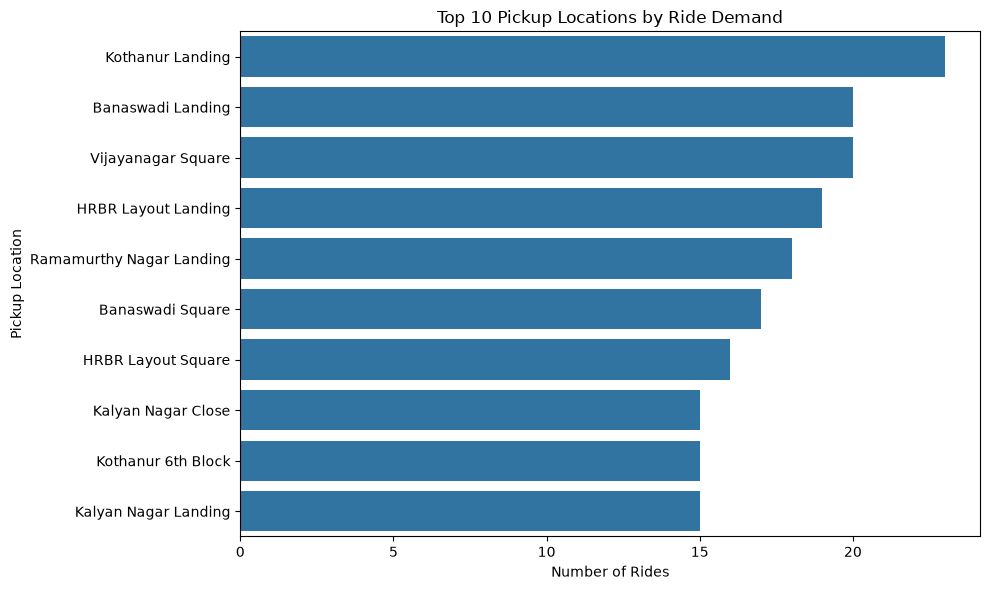

In [44]:
top_sources = source_analysis.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_sources,
    x='Total_Rides',
    y='source'
)

plt.title('Top 10 Pickup Locations by Ride Demand')
plt.xlabel('Number of Rides')
plt.ylabel('Pickup Location')

plt.tight_layout()
plt.show()

In [45]:
destination_analysis = (
    df.groupby('destination')
      .agg(
          Total_Rides=('ride_id', 'count'),
          Total_Revenue=('total_fare', 'sum'),
          Average_Fare=('total_fare', 'mean')
      )
      .reset_index()
      .sort_values('Total_Rides', ascending=False)
)

destination_analysis.head(10)

,destination,Total_Rides,Total_Revenue,Average_Fare
4571,Gottigere Landing,23,10633.41,462.322174
4595,Gottigere Square,20,10447.75,522.387500
8440,Kudlu Square,17,8451.54,497.149412
4646,HRBR Layout Drive,17,8814.62,518.507059
5838,Hulimavu Drive,16,9418.57,588.660625
4534,Gottigere 6th Block,16,8103.54,506.471250
4827,Harohalli Landing,16,6355.81,397.238125
6650,Kadubeesanahalli Square,15,7592.27,506.151333
4683,HRBR Layout Square,15,9037.10,602.473333
10771,Ramamurthy Nagar 6th Block,15,7451.05,496.736667


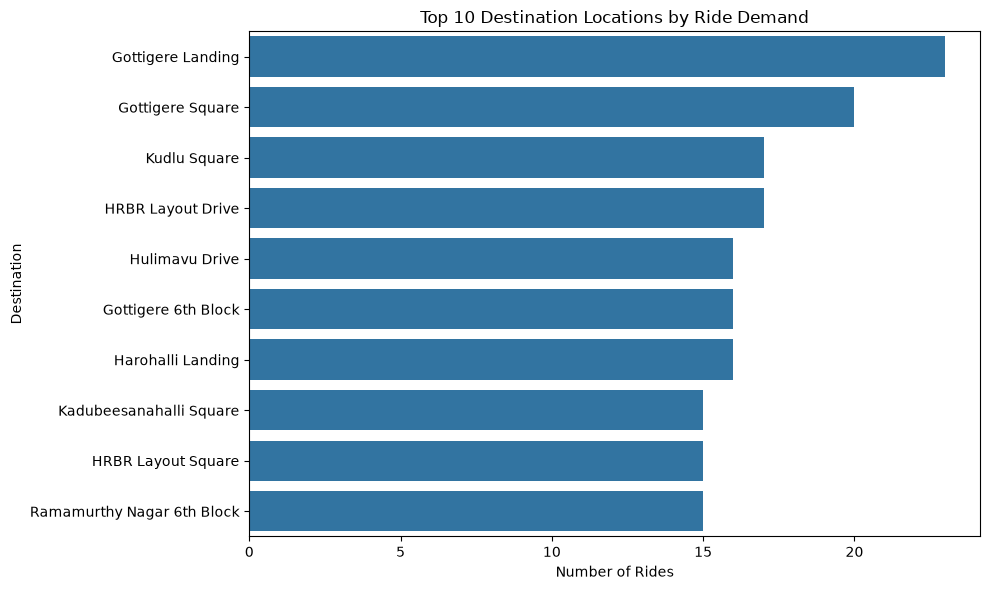

In [46]:
top_destinations = destination_analysis.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_destinations,
    x='Total_Rides',
    y='destination'
)

plt.title('Top 10 Destination Locations by Ride Demand')
plt.xlabel('Number of Rides')
plt.ylabel('Destination')

plt.tight_layout()
plt.show()

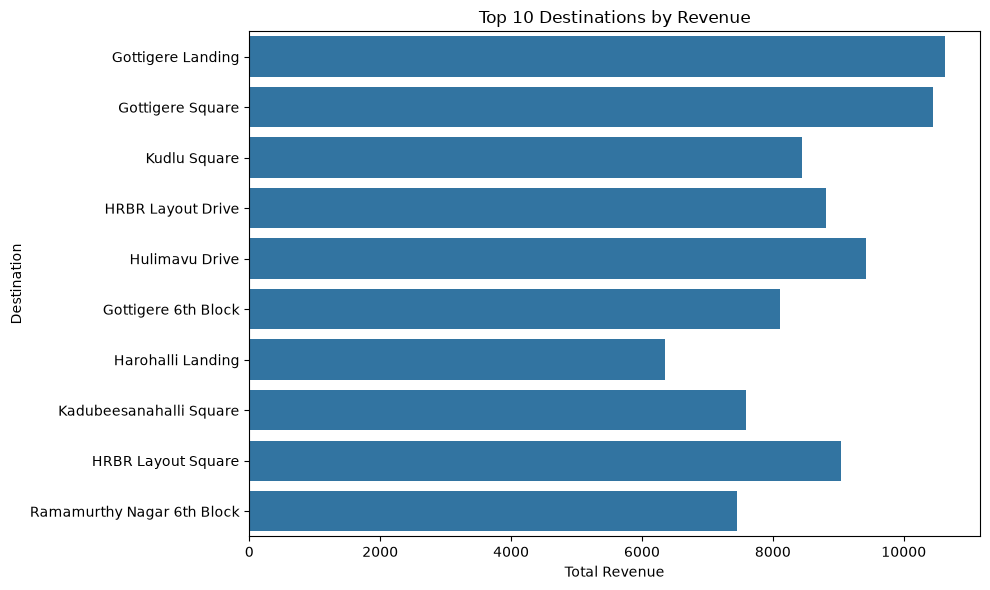

In [47]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_destinations,
    x='Total_Revenue',
    y='destination'
)

plt.title('Top 10 Destinations by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Destination')

plt.tight_layout()
plt.show()

In [48]:
distance_analysis = (
    df.groupby('Distance_Category')
      .agg(
          Total_Rides=('ride_id', 'count'),
          Total_Revenue=('total_fare', 'sum'),
          Average_Fare=('total_fare', 'mean'),
          Average_Distance=('distance', 'mean')
      )
      .reset_index()
)

distance_analysis

,Distance_Category,Total_Rides,Total_Revenue,Average_Fare,Average_Distance
0,Long,8120,4045353.06,498.196190,10.979469
1,Medium,4081,1999964.37,490.067231,5.003308
2,Short,2052,1008618.39,491.529430,2.002870
3,Very Long,35747,17559047.23,491.203380,32.526659


In [49]:
category_order = ['Short', 'Medium', 'Long', 'Very Long']

distance_analysis['Distance_Category'] = pd.Categorical(
    distance_analysis['Distance_Category'],
    categories=category_order,
    ordered=True
)

distance_analysis = distance_analysis.sort_values('Distance_Category')

distance_analysis

,Distance_Category,Total_Rides,Total_Revenue,Average_Fare,Average_Distance
2,Short,2052,1008618.39,491.529430,2.002870
1,Medium,4081,1999964.37,490.067231,5.003308
0,Long,8120,4045353.06,498.196190,10.979469
3,Very Long,35747,17559047.23,491.203380,32.526659


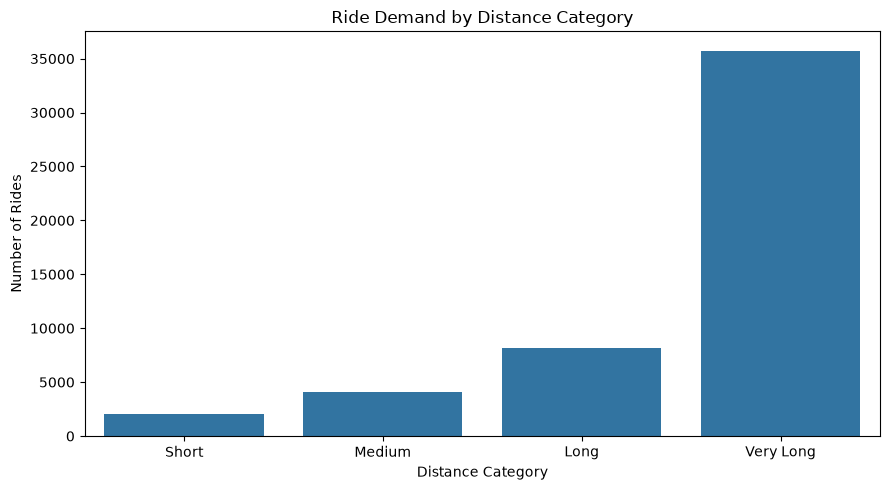

In [50]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=distance_analysis,
    x='Distance_Category',
    y='Total_Rides'
)

plt.title('Ride Demand by Distance Category')
plt.xlabel('Distance Category')
plt.ylabel('Number of Rides')

plt.tight_layout()
plt.show()

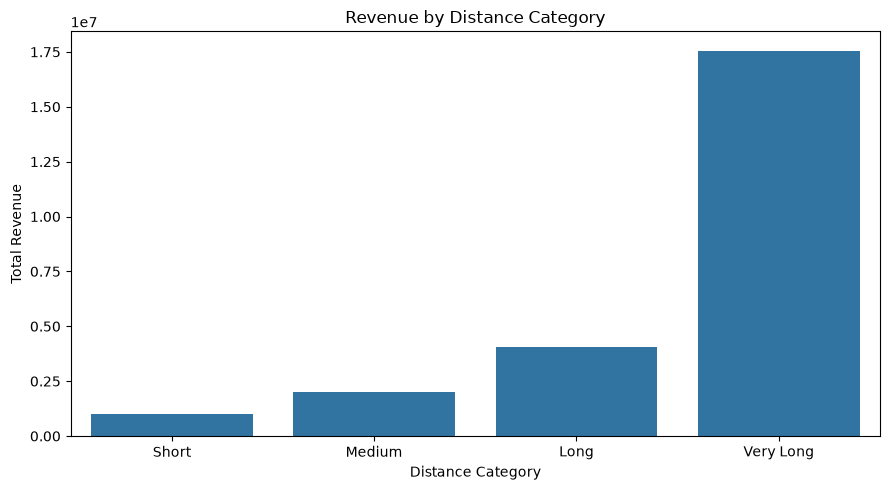

In [51]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=distance_analysis,
    x='Distance_Category',
    y='Total_Revenue'
)

plt.title('Revenue by Distance Category')
plt.xlabel('Distance Category')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

In [52]:
payment_analysis = (
    df.groupby('payment_method')
      .agg(
          Total_Rides=('ride_id', 'count'),
          Total_Revenue=('total_fare', 'sum'),
          Average_Fare=('total_fare', 'mean')
      )
      .reset_index()
      .sort_values('Total_Rides', ascending=False)
)

payment_analysis

,payment_method,Total_Rides,Total_Revenue,Average_Fare
3,Paytm,11315,6201171.55,548.048745
1,GPay,11268,6171005.26,547.657549
0,Amazon Pay,11225,6131641.87,546.248719
4,QR scan,11156,6109164.37,547.612439
2,Not Applicable,5036,0.00,0.000000


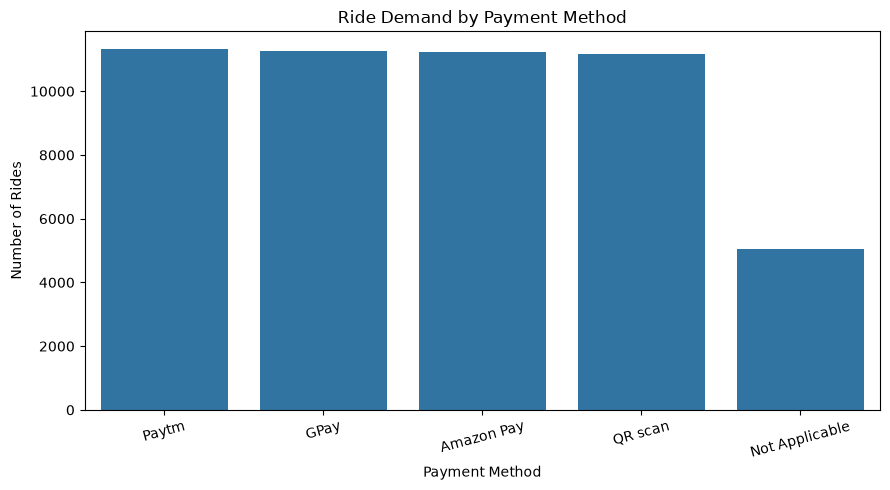

In [53]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=payment_analysis,
    x='payment_method',
    y='Total_Rides'
)

plt.title('Ride Demand by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Rides')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

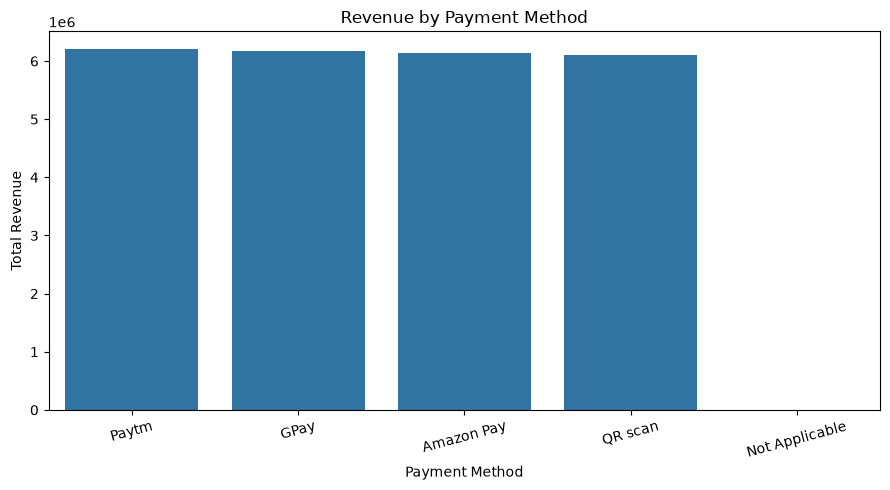

In [54]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=payment_analysis,
    x='payment_method',
    y='Total_Revenue'
)

plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [55]:
status_analysis = (
    df.groupby('ride_status')
      .agg(
          Total_Rides=('ride_id', 'count'),
          Total_Revenue=('total_fare', 'sum'),
          Average_Fare=('total_fare', 'mean')
      )
      .reset_index()
)

status_analysis

,ride_status,Total_Rides,Total_Revenue,Average_Fare
0,cancelled,5036,0.00,0.000000
1,completed,44964,24612983.05,547.393093


In [56]:
total_rides = len(df)

cancelled_rides = (df['ride_status'] == 'cancelled').sum()

cancellation_rate = cancelled_rides / total_rides * 100

print(f"Cancellation Rate: {cancellation_rate:.2f}%")

Cancellation Rate: 10.07%


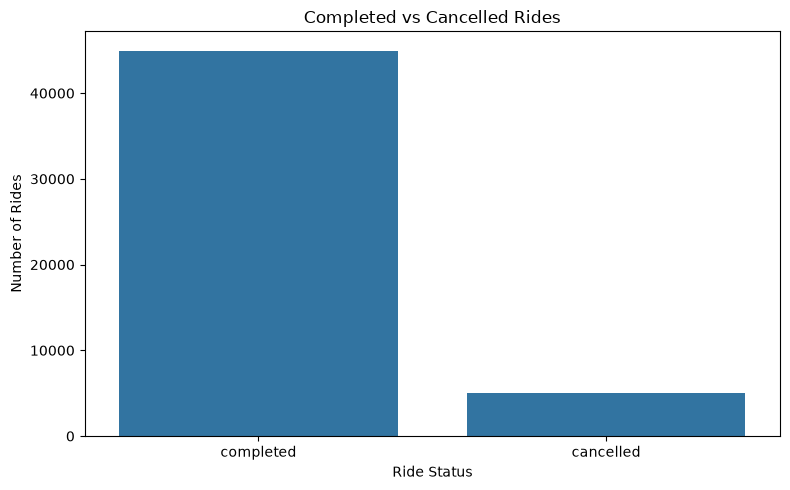

In [57]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='ride_status'
)

plt.title('Completed vs Cancelled Rides')
plt.xlabel('Ride Status')
plt.ylabel('Number of Rides')

plt.tight_layout()
plt.show()

In [58]:
cancellation_by_service = (
    df.groupby('services')
      .agg(
          Total_Rides=('ride_id', 'count'),
          Cancelled_Rides=('ride_status', lambda x: (x == 'cancelled').sum()),
          Completed_Rides=('ride_status', lambda x: (x == 'completed').sum())
      )
      .reset_index()
)

cancellation_by_service['Cancellation_Rate'] = (
    cancellation_by_service['Cancelled_Rides'] /
    cancellation_by_service['Total_Rides'] * 100
).round(2)

cancellation_by_service = cancellation_by_service.sort_values(
    'Cancellation_Rate',
    ascending=False
)

cancellation_by_service

,services,Total_Rides,Cancelled_Rides,Completed_Rides,Cancellation_Rate
3,cab economy,10202,1054,9148,10.33
1,bike,15128,1561,13567,10.32
2,bike lite,4884,496,4388,10.16
0,auto,12327,1213,11114,9.84
4,parcel,7459,712,6747,9.55


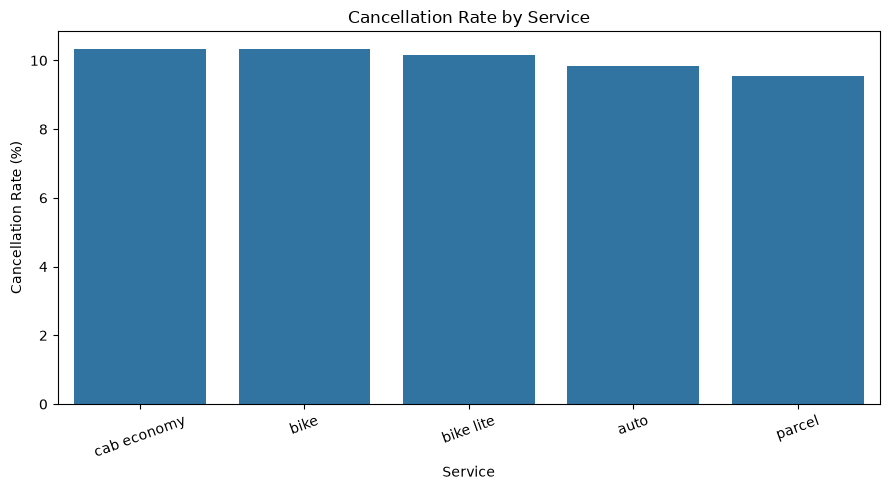

In [59]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=cancellation_by_service,
    x='services',
    y='Cancellation_Rate'
)

plt.title('Cancellation Rate by Service')
plt.xlabel('Service')
plt.ylabel('Cancellation Rate (%)')

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [60]:
df.to_csv('rapido_final_data.csv', index=False)

print("Final dataset exported successfully!")
print(df.shape)

Final dataset exported successfully!
(50000, 20)
